In [8]:
##### Creates maps of agricultural capital and labor intensities 
# Side-by-side of pixel intensities and country intensities 

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from glob import glob
import rasterio
from rasterio.warp import reproject, Resampling
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from pyproj import Transformer
import matplotlib.patches as mpatches
from matplotlib.colors import to_hex, Normalize
from matplotlib import cm
import matplotlib
from matplotlib.patches import Rectangle
from rasterstats import zonal_stats
from scipy.stats import gaussian_kde

In [2]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# pixel data
capital_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/capital_intensity_USD_per_tonne.tif")
labor_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/labor_intensity_jobs_per_tonne.tif")

# sub-national data 
sub_national_capital = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_capital_intensity.csv")
sub_national_labor = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_labor_intensity.csv")
sub_national_capital_geo = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_capital.shp")
sub_national_labor_geo = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_labor.shp")

modelled_sub_capital = pd.read_csv(f"{cd}/Results/Raster_model/sub_national_intensities/capital_intensity_subnational.csv")
modelled_sub_labor = pd.read_csv(f"{cd}/Results/Raster_model/sub_national_intensities/labor_intensity_subnational.csv")

# national data
country_intensities = pd.read_csv(f"{cd}/Data/Clean/Intensities/country_intensities.csv")
country_boundaries = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")
country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

has_data = pd.read_csv(f'{cd}/Data/Correspondence_tables/has_data.csv')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/map_intensity_side_by_side"

In [3]:
### Data prep

target_crs = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"

capital_intensity = capital_intensity.rio.reproject(target_crs)

labor_intensity = labor_intensity.rio.reproject_match(capital_intensity)

country_boundaries = country_boundaries.to_crs(capital_intensity.rio.crs)
sub_national_capital_geo = sub_national_capital_geo.to_crs(capital_intensity.rio.crs)
sub_national_labor_geo = sub_national_labor_geo.to_crs(capital_intensity.rio.crs)

# add geo to country / sub-national intensities 
country_boundaries = country_boundaries.merge(country_intensities, on='ISO3', how='left')

sub_national_capital = sub_national_capital_geo.merge(sub_national_capital, on='PROJ_ID', how='left')
sub_national_labor = sub_national_labor_geo.merge(sub_national_labor, on='PROJ_ID', how='left')

In [4]:
##### Identify no data countries 

country_boundaries = country_boundaries.merge(has_data, on='SHP_code', how='left')
country_boundaries['has_capital_data'] = country_boundaries['has_capital_data'].fillna(0)
country_boundaries['has_labor_data'] = country_boundaries['has_labor_data'].fillna(0)

#### Map intensity rasters

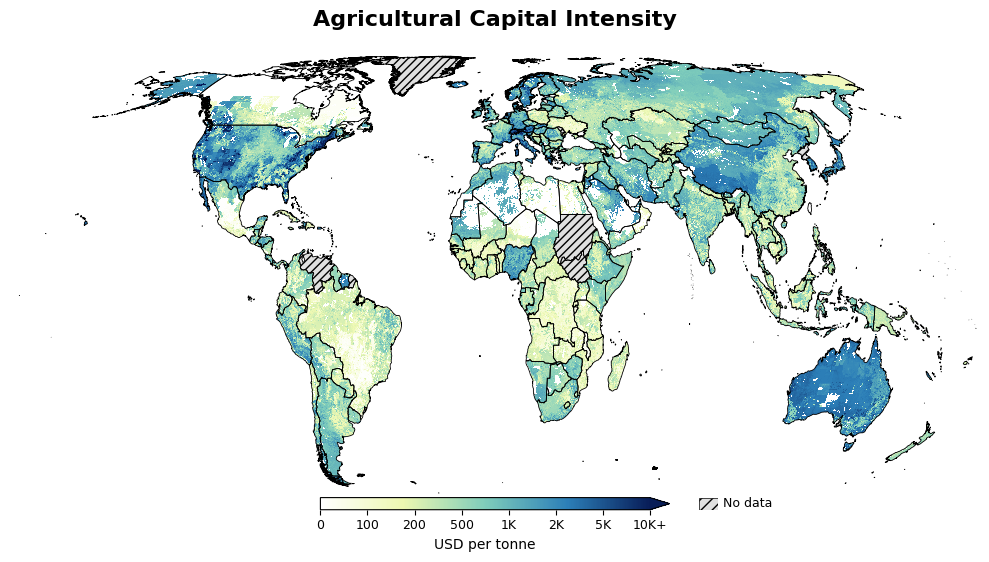

In [5]:
##### Produce global map of capital intensity

# Prepare raster
value_plot = capital_intensity.squeeze()
name = 'capital_intensity'

# set custom colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "white_ylgnbu",
    ["#ffffff", "#edf8b1", "#7fcdbb", "#2c7fb8", "#081d58"]
)
custom_cmap.set_over("#081d58")  # color for the + triangle

# Set special equal-distant, manual scalling
bounds = [0, 100, 200, 500, 1000, 2000, 5000, 10000]      
labels = ['0', '100', '200', '500', '1K', '2K', '5K', '10K+']            

positions = np.linspace(0, 1, len(bounds))  # each bound gets an equal-width slice

def forward(x):
    return np.interp(x, bounds, positions)

def inverse(x):
    return np.interp(x, positions, bounds)

norm = mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Countries with no data (light grey fill with hatching)
no_data_color = "#e0e0e0"
country_boundaries[country_boundaries["has_capital_data"] == 0].plot(
    ax=ax,
    facecolor=no_data_color,
    edgecolor="none",
    hatch="////",
    zorder=0
)

# Country borders
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap=custom_cmap,
    norm=norm,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

ax.set_axis_off()
ax.set_title("Agricultural Capital Intensity", fontsize=16, weight='bold', pad=20)

# Generate legend 
cax = ax.inset_axes([0.32, 0.06, 0.36, 0.025], transform=ax.transAxes)

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    extend='max',       
    extendfrac=0.06,    
)
cbar.set_label("USD per tonne", fontsize=10)
cbar.ax.tick_params(labelsize=9)

cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

# Add no data to legend
legend_ax = ax.inset_axes([0.71, 0.06, 0.02, 0.025], transform=ax.transAxes)
legend_ax.add_patch(Rectangle(
    (0, 0), 1, 1,
    facecolor=no_data_color,
    edgecolor="black",
    linewidth=0.5,
    hatch="///"
))
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.set_xticks([])
legend_ax.set_yticks([])
legend_ax.axis("off")

ax.text(
    0.735, 0.072, "No data",
    transform=ax.transAxes,
    fontsize=9, va="center", ha="left"
)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

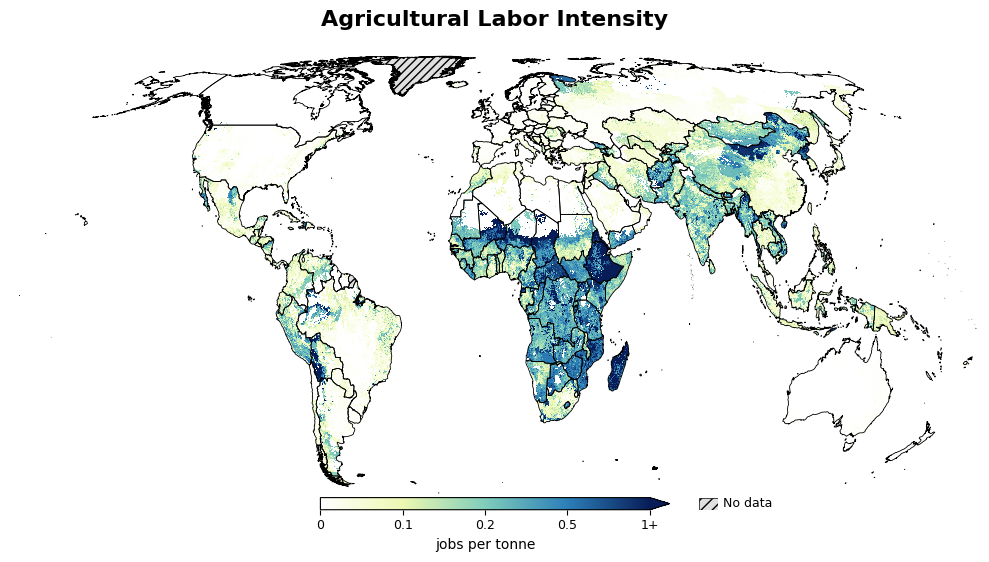

In [6]:
##### Produce global map of labor intensity

# Prepare raster
value_plot = labor_intensity.squeeze()
name = 'labor_intensity'

# set custom colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "white_ylgnbu",
    ["#ffffff", "#edf8b1", "#7fcdbb", "#2c7fb8", "#081d58"]
)
custom_cmap.set_over("#081d58")  # color for the + triangle

# Set special equal-distant, manual scalling
bounds = [0, 0.1, 0.2, 0.5, 1]      
labels = ['0', '0.1', '0.2', '0.5', '1+']            

positions = np.linspace(0, 1, len(bounds))  # each bound gets an equal-width slice

def forward(x):
    return np.interp(x, bounds, positions)

def inverse(x):
    return np.interp(x, positions, bounds)

norm = mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Countries with no data (light grey fill with hatching)
no_data_color = "#e0e0e0"
country_boundaries[country_boundaries["has_labor_data"] == 0].plot(
    ax=ax,
    facecolor=no_data_color,
    edgecolor="none",
    hatch="////",
    zorder=0
)

# Country borders
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap=custom_cmap,
    norm=norm,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

ax.set_axis_off()
ax.set_title("Agricultural Labor Intensity", fontsize=16, weight='bold', pad=20)

# Generate legend 
cax = ax.inset_axes([0.32, 0.06, 0.36, 0.025], transform=ax.transAxes)

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    extend='max',       
    extendfrac=0.06,    
)
cbar.set_label("jobs per tonne", fontsize=10)
cbar.ax.tick_params(labelsize=9)

cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

# Add no data to legend
legend_ax = ax.inset_axes([0.71, 0.06, 0.02, 0.025], transform=ax.transAxes)
legend_ax.add_patch(Rectangle(
    (0, 0), 1, 1,
    facecolor=no_data_color,
    edgecolor="black",
    linewidth=0.5,
    hatch="///"
))
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.set_xticks([])
legend_ax.set_yticks([])
legend_ax.axis("off")

ax.text(
    0.735, 0.072, "No data",
    transform=ax.transAxes,
    fontsize=9, va="center", ha="left"
)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

#### Map intensities side-by-side

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_90111/3147944426.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_ax.boxplot(
/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_90111/3147944426.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_ax.boxplot(


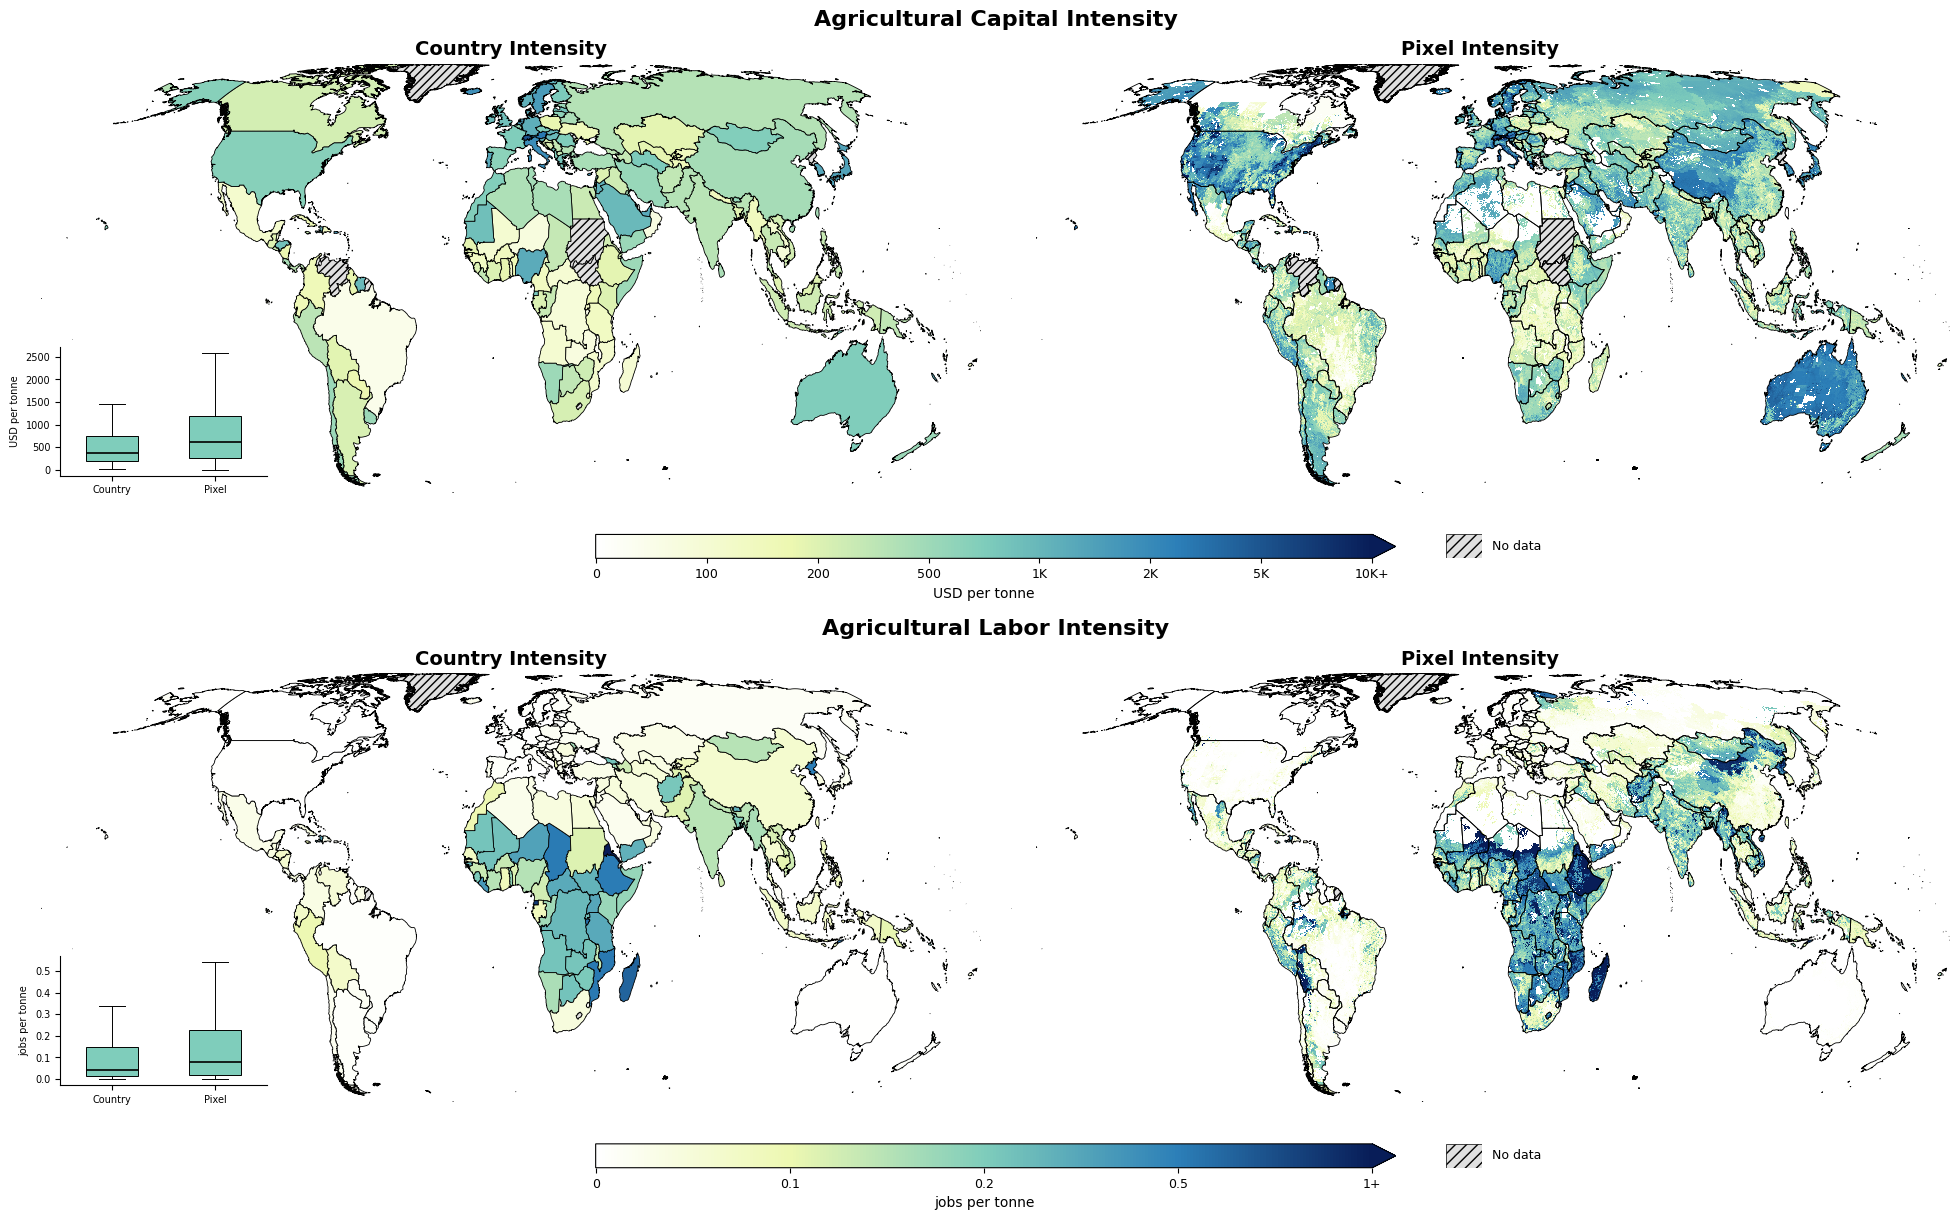

In [13]:
##### Stacked capital/labor intensity comparison with distribution insets

def plot_intensity_stacked(specs, country_gdf, out_path, missing_color="#e0e0e0"):
    minx, miny, maxx, maxy = country_gdf.total_bounds
    data_w = maxx - minx
    data_h = maxy - miny

    fig_width = 20
    panel_width = fig_width / 2
    map_height = panel_width * (data_h / data_w)
    row_height = map_height + 1.4
    fig_height = row_height * 2

    fig, axes = plt.subplots(2, 2, figsize=(fig_width, fig_height))

    for row_idx, spec in enumerate(specs):
        raster = spec["raster"]
        value_col = spec["value_col"]
        coverage_col = spec["coverage_col"]
        bounds = spec["bounds"]
        labels = spec["labels"]
        cbar_label = spec["cbar_label"]

        value_plot = raster.squeeze()

        cmap = mcolors.LinearSegmentedColormap.from_list(
            "white_ylgnbu",
            ["#ffffff", "#edf8b1", "#7fcdbb", "#2c7fb8", "#081d58"]
        )
        cmap.set_over("#081d58")

        positions = np.linspace(0, 1, len(bounds))

        def forward(x, bounds=bounds, positions=positions):
            return np.interp(x, bounds, positions)

        def inverse(x, bounds=bounds, positions=positions):
            return np.interp(x, positions, bounds)

        norm = mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])

        ax0 = axes[row_idx, 0]
        ax1 = axes[row_idx, 1]

        # --- Panel 1: country-level choropleth ---
        country_has_data = country_gdf[country_gdf[coverage_col] == 1]
        country_no_data = country_gdf[country_gdf[coverage_col] == 0]

        country_no_data.plot(ax=ax0, facecolor=missing_color, edgecolor="black", linewidth=0.6, hatch="////", zorder=1)
        country_has_data.plot(
            ax=ax0, column=value_col, cmap=cmap, norm=norm,
            edgecolor="black", linewidth=0.6, zorder=2
        )

        ax0.set_xlim(minx, maxx)
        ax0.set_ylim(miny, maxy)
        ax0.set_aspect("equal")
        ax0.set_axis_off()
        ax0.set_title("Country Intensity", fontsize=14, weight="bold")

        # --- Panel 2: pixel intensity ---
        country_gdf[country_gdf[coverage_col] == 0].plot(
            ax=ax1, facecolor=missing_color, edgecolor="black", linewidth=0.6, hatch="////", zorder=1
        )

        im = value_plot.plot(
            ax=ax1, cmap=cmap, norm=norm,
            add_colorbar=False, add_labels=False, zorder=2
        )

        country_gdf.plot(ax=ax1, facecolor="none", edgecolor="black", linewidth=0.6, zorder=3)

        ax1.set_xlim(minx, maxx)
        ax1.set_ylim(miny, maxy)
        ax1.set_aspect("equal")
        ax1.set_axis_off()
        ax1.set_title("Pixel Intensity", fontsize=14, weight="bold")

        # --- Boxplot inset (this stays here — inset_axes is relative to ax0, so it's layout-safe) ---
        country_vals = country_has_data[value_col].dropna().values
        pixel_vals = np.asarray(value_plot.values).ravel()
        pixel_vals = pixel_vals[np.isfinite(pixel_vals)]
        pixel_vals = pixel_vals[pixel_vals > 0]

        box_ax = ax0.inset_axes([0.02, 0.04, 0.22, 0.30], transform=ax0.transAxes)
        box_ax.boxplot(
            [country_vals, pixel_vals],
            labels=["Country", "Pixel"],
            widths=0.5,
            showfliers=False,
            patch_artist=True,
            boxprops=dict(facecolor="#7fcdbb", edgecolor="black", linewidth=0.7),
            medianprops=dict(color="black", linewidth=1.2),
            whiskerprops=dict(linewidth=0.7),
            capprops=dict(linewidth=0.7),
        )
        box_ax.set_facecolor("white")
        box_ax.patch.set_alpha(0.85)
        box_ax.tick_params(labelsize=7)
        box_ax.set_ylabel(cbar_label, fontsize=7)
        for spine in ["top", "right"]:
            box_ax.spines[spine].set_visible(False)

    # --- Finalize layout FIRST — everything placed with fig.text/fig.add_axes must come after this ---
    fig.subplots_adjust(left=0.02, right=0.98, top=0.93, bottom=0.06, hspace=0.42, wspace=0.02)
    fig.canvas.draw()

    # --- NOW place row titles, using each row's true post-layout axes positions ---
    for row_idx, spec in enumerate(specs):
        ax0 = axes[row_idx, 0]
        ax1 = axes[row_idx, 1]

        title_bbox = ax0.title.get_window_extent(renderer=fig.canvas.get_renderer())
        title_bbox_fig = title_bbox.transformed(fig.transFigure.inverted())

        row_pos_left = ax0.get_position()
        row_pos_right = ax1.get_position()
        fig.text(
            (row_pos_left.x0 + row_pos_right.x1) / 2,
            title_bbox_fig.y1 + 0.012,
            spec["row_title"], fontsize=16, weight="bold", ha="center"
        )

    # --- Per-row shared colorbar + no-data legend (unchanged from before) ---
    for row_idx, spec in enumerate(specs):
        bounds = spec["bounds"]
        labels = spec["labels"]
        cbar_label = spec["cbar_label"]

        ax0 = axes[row_idx, 0]
        ax1 = axes[row_idx, 1]
        pos0 = ax0.get_position()
        pos1 = ax1.get_position()

        cbar_width = 0.4
        cbar_x0 = (pos0.x0 + pos1.x1) / 2 - cbar_width / 2
        cbar_y0 = pos0.y0 - 0.055
        cbar_height = 0.02

        cbar_ax = fig.add_axes([cbar_x0, cbar_y0, cbar_width, cbar_height])

        cmap = mcolors.LinearSegmentedColormap.from_list(
            "white_ylgnbu",
            ["#ffffff", "#edf8b1", "#7fcdbb", "#2c7fb8", "#081d58"]
        )
        cmap.set_over("#081d58")
        positions = np.linspace(0, 1, len(bounds))

        def forward(x, bounds=bounds, positions=positions):
            return np.interp(x, bounds, positions)

        def inverse(x, bounds=bounds, positions=positions):
            return np.interp(x, positions, bounds)

        norm = mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

        cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", extend='max', extendfrac=0.03)
        cbar.set_label(cbar_label, fontsize=10)
        cbar.ax.tick_params(labelsize=9)
        cbar.set_ticks(bounds)
        cbar.set_ticklabels(labels)

        swatch_size = 0.018
        gap = 0.025
        legend_ax = fig.add_axes([cbar_x0 + cbar_width + gap, cbar_y0, swatch_size, cbar_height])
        legend_ax.add_patch(mpatches.Rectangle(
            (0, 0), 1, 1, facecolor=missing_color, edgecolor="black", linewidth=0.5, hatch="///"
        ))
        legend_ax.set_xlim(0, 1); legend_ax.set_ylim(0, 1)
        legend_ax.set_xticks([]); legend_ax.set_yticks([])
        legend_ax.axis("off")

        fig.text(
            cbar_x0 + cbar_width + gap + swatch_size + 0.005,
            cbar_y0 + cbar_height / 2,
            "No data", fontsize=9, va="center", ha="left"
        )

    fig.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0.1)
    plt.show()


# --- Build the combined figure ---
specs = [
    dict(
        raster=capital_intensity,
        value_col="capital_intensity_USD_per_tonne",
        coverage_col="has_capital_data",
        bounds=[0, 100, 200, 500, 1000, 2000, 5000, 10000],
        labels=['0', '100', '200', '500', '1K', '2K', '5K', '10K+'],
        row_title="Agricultural Capital Intensity",
        cbar_label="USD per tonne",
    ),
    dict(
        raster=labor_intensity,
        value_col="labor_intensity_jobs_per_tonne",
        coverage_col="has_labor_data",
        bounds=[0, 0.1, 0.2, 0.5, 1],
        labels=['0', '0.1', '0.2', '0.5', '1+'],
        row_title="Agricultural Labor Intensity",
        cbar_label="jobs per tonne",
    ),
]

plot_intensity_stacked(
    specs, country_boundaries,
    out_path=f"{fd}/capital_labor_intensity_stacked.png"
)

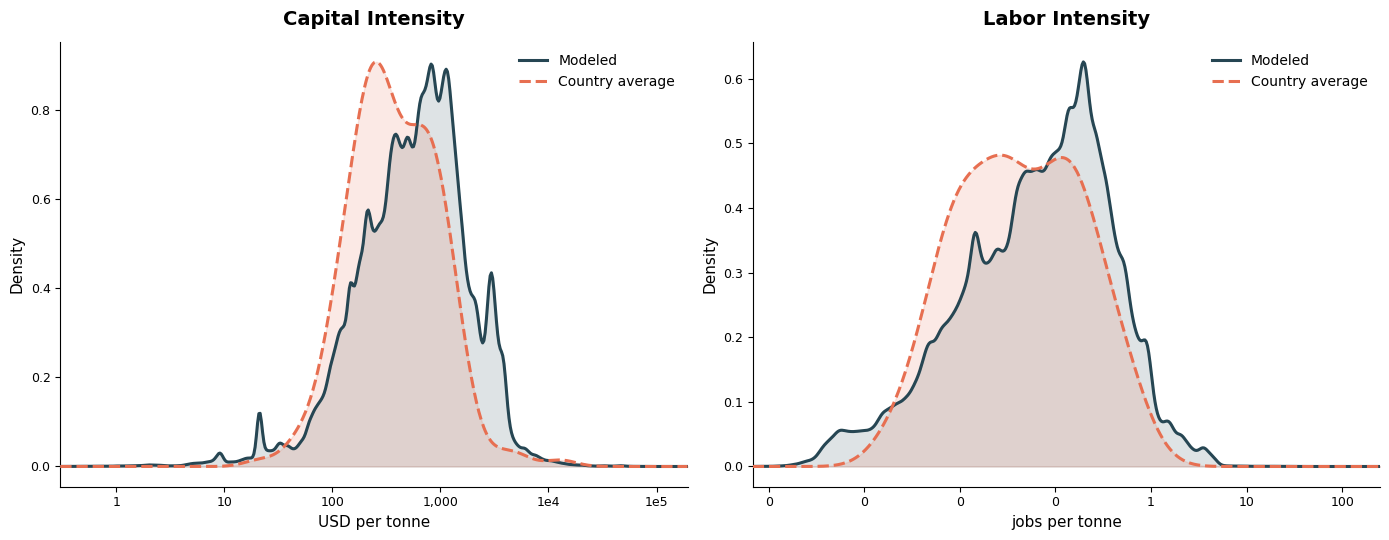

In [9]:
##### Density plot: modeled (pixel-level) vs. country-average intensities (from country_boundaries)

def _to_flat_array(a):
    if hasattr(a, "values"):
        a = a.values
    a = np.asarray(a)
    return a.ravel()

def plot_intensity_density(ax, modeled, country_avg, title, axis_label):
    modeled = _to_flat_array(modeled)
    country_avg = _to_flat_array(country_avg)

    # keep only strictly positive, finite values (required for log10)
    modeled = modeled[(modeled > 0) & np.isfinite(modeled)]
    country_avg = country_avg[(country_avg > 0) & np.isfinite(country_avg)]

    log_modeled = np.log10(modeled)
    log_country = np.log10(country_avg)

    lo = min(log_modeled.min(), log_country.min())
    hi = max(log_modeled.max(), log_country.max())
    xs = np.linspace(lo, hi, 500)

    kde_modeled = gaussian_kde(log_modeled)
    kde_country = gaussian_kde(log_country)

    color_modeled = "#264653"   # dark teal
    color_country = "#e76f51"   # coral

    ax.plot(xs, kde_modeled(xs), color=color_modeled, linewidth=2.2, linestyle='-', label='Modeled', zorder=3)
    ax.fill_between(xs, kde_modeled(xs), color=color_modeled, alpha=0.15, zorder=2)

    ax.plot(xs, kde_country(xs), color=color_country, linewidth=2.2, linestyle='--', label='Country average', zorder=3)
    ax.fill_between(xs, kde_country(xs), color=color_country, alpha=0.15, zorder=2)

    tick_locs = np.arange(np.floor(lo), np.ceil(hi) + 1)
    tick_labels = [f"{10**t:,.0f}" if t < 4 else f"{10**t:.0e}".replace("e+0", "e").replace("e+", "e")
                   for t in tick_locs]
    ax.set_xticks(tick_locs)
    ax.set_xticklabels(tick_labels, rotation=0)
    ax.set_xlim(lo, hi)

    ax.set_xlabel(axis_label, fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(title, fontsize=14, weight='bold', pad=12)
    ax.legend(fontsize=10, frameon=False, loc='upper right')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=9)


# ================= BUILD FIGURE =================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

plot_intensity_density(
    axes[0], capital_intensity, country_boundaries['capital_intensity_USD_per_tonne'],
    "Capital Intensity", "USD per tonne"
)
plot_intensity_density(
    axes[1], labor_intensity, country_boundaries['labor_intensity_jobs_per_tonne'],
    "Labor Intensity", "jobs per tonne"
)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/intensity_density_comparison.png", dpi=300, bbox_inches='tight')

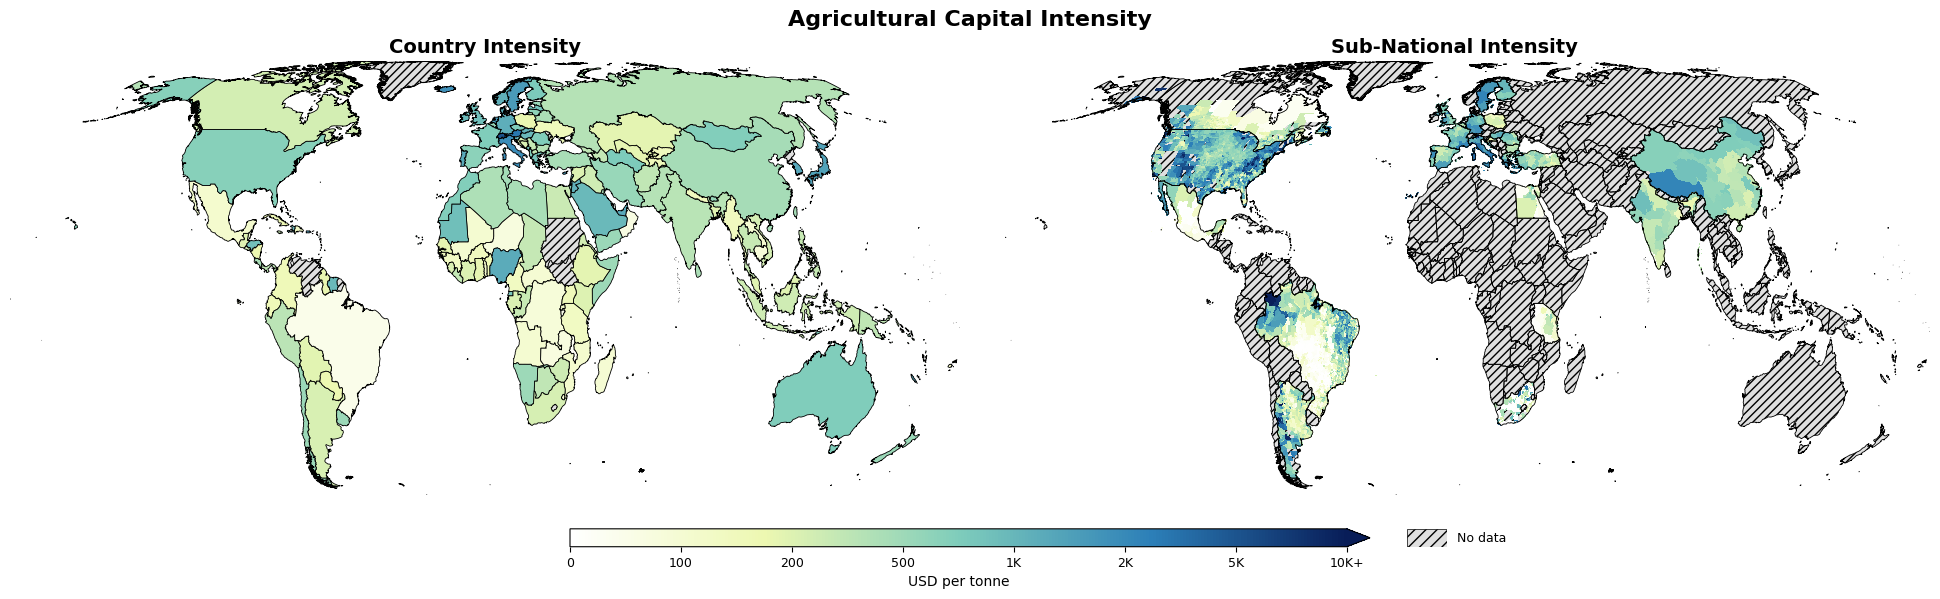

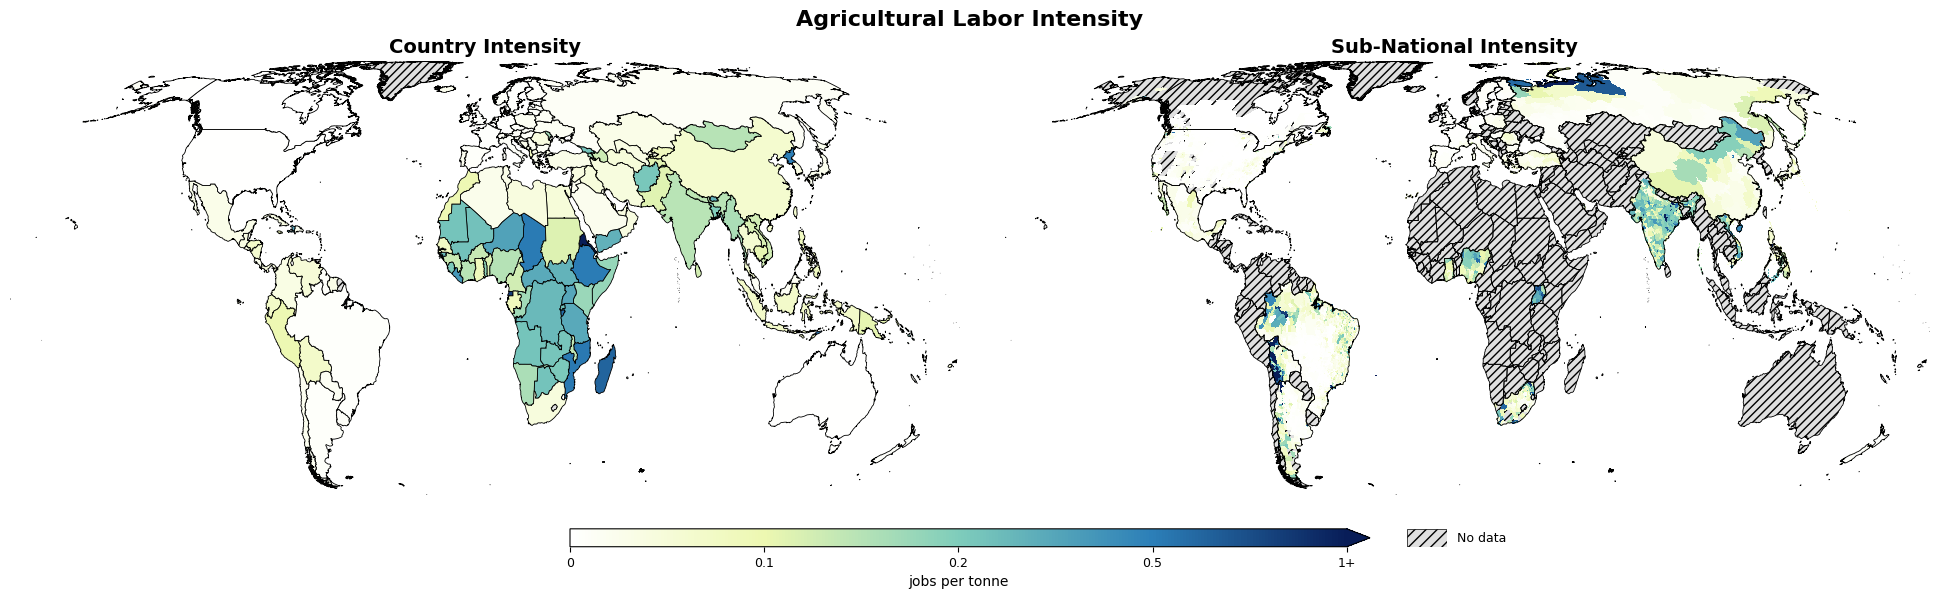

In [11]:
#### Map country and sub-national intensities side-by-side

def plot_intensity_country_vs_subnational(
    subnational_gdf, country_gdf, value_col, country_coverage_col, bounds, labels,
    title, cbar_label, out_path, cmap=None, missing_color="#e0e0e0"
):

    minx, miny, maxx, maxy = country_gdf.total_bounds

    # --- Custom white -> YlGnBu colormap (shared default, matches other intensity maps) ---
    if cmap is None:
        cmap = mcolors.LinearSegmentedColormap.from_list(
            "white_ylgnbu",
            ["#ffffff", "#edf8b1", "#7fcdbb", "#2c7fb8", "#081d58"]
        )
        cmap.set_over("#081d58")

    # --- Piecewise-linear scaling: equal spacing between bounds, regardless of real magnitude ---
    positions = np.linspace(0, 1, len(bounds))

    def forward(x):
        return np.interp(x, bounds, positions)

    def inverse(x):
        return np.interp(x, positions, bounds)

    norm = mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])

    # --- Compute figure height from actual data aspect ratio to kill excess whitespace ---
    data_w = maxx - minx
    data_h = maxy - miny
    fig_width = 20
    panel_width = fig_width / 2
    map_height = panel_width * (data_h / data_w)
    fig_height = map_height + 1.4

    fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_height))

    # --- Panel 1: country-level choropleth ---
    ax0 = axes[0]

    country_has_data = country_gdf[country_gdf[country_coverage_col] == 1]
    country_no_data = country_gdf[country_gdf[country_coverage_col] == 0]

    country_no_data.plot(ax=ax0, facecolor=missing_color, edgecolor="black", linewidth=0.6, hatch="////", zorder=1)
    country_has_data.plot(
        ax=ax0, column=value_col, cmap=cmap, norm=norm,
        edgecolor="black", linewidth=0.6, zorder=2
    )

    ax0.set_xlim(minx, maxx)
    ax0.set_ylim(miny, maxy)
    ax0.set_aspect("equal")
    ax0.set_axis_off()
    ax0.set_title("Country Intensity", fontsize=14, weight="bold")

    # --- Panel 2: sub-national choropleth ---
    ax1 = axes[1]

    # background: fill ALL countries with the no-data hatch first; sub-national
    # polygons with data will simply draw on top and cover it up wherever they exist
    country_gdf.plot(ax=ax1, facecolor=missing_color, edgecolor="none", hatch="////", zorder=1)

    im = subnational_gdf.plot(
        ax=ax1, column=value_col, cmap=cmap, norm=norm,
        edgecolor="none", linewidth=0, antialiased=False, zorder=2
    )

    country_gdf.plot(ax=ax1, facecolor="none", edgecolor="black", linewidth=0.6, zorder=3)

    ax1.set_xlim(minx, maxx)
    ax1.set_ylim(miny, maxy)
    ax1.set_aspect("equal")
    ax1.set_axis_off()
    ax1.set_title("Sub-National Intensity", fontsize=14, weight="bold")

    fig.suptitle(title, fontsize=16, weight="bold", y=0.98)

    # --- Tighten margins so panels fill the figure ---
    fig.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.16, wspace=0.02)

    # --- Shared horizontal colorbar along the bottom, with "+" triangle ---
    # geopandas .plot() with a column doesn't return a mappable directly, so build one for the colorbar
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar_ax = fig.add_axes([0.30, 0.08, 0.4, 0.03])
    cbar = fig.colorbar(
        sm, cax=cbar_ax, orientation="horizontal",
        extend='max', extendfrac=0.03,
    )
    cbar.set_label(cbar_label, fontsize=10)
    cbar.ax.tick_params(labelsize=9)
    cbar.set_ticks(bounds)
    cbar.set_ticklabels(labels)

    # --- Missing-data legend, positioned next to the colorbar ---
    fig.canvas.draw()
    cbar_pos = cbar.ax.get_position()

    swatch_size = 0.02
    gap = 0.03

    legend_ax = fig.add_axes([
        cbar_pos.x1 + gap,
        cbar_pos.y0,
        swatch_size,
        cbar_pos.height
    ])
    legend_ax.add_patch(mpatches.Rectangle(
        (0, 0), 1, 1,
        facecolor=missing_color,
        edgecolor="black",
        linewidth=0.5,
        hatch="///"
    ))
    legend_ax.set_xlim(0, 1)
    legend_ax.set_ylim(0, 1)
    legend_ax.set_xticks([])
    legend_ax.set_yticks([])
    legend_ax.axis("off")

    fig.text(
        cbar_pos.x1 + gap + swatch_size + 0.005,
        cbar_pos.y0 + cbar_pos.height / 2,
        "No data",
        fontsize=9, va="center", ha="left"
    )

    fig.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0.1)
    plt.show()


plot_intensity_country_vs_subnational(
    subnational_gdf=sub_national_capital,
    country_gdf=country_boundaries,
    value_col="capital_intensity_USD_per_tonne",
    country_coverage_col="has_capital_data",
    bounds=[0, 100, 200, 500, 1000, 2000, 5000, 10000],
    labels=['0', '100', '200', '500', '1K', '2K', '5K', '10K+'],
    title="Agricultural Capital Intensity",
    cbar_label="USD per tonne",
    out_path=f"{fd}/capital_intensity_country_vs_subnational.png",
)

plot_intensity_country_vs_subnational(
    subnational_gdf=sub_national_labor,
    country_gdf=country_boundaries,
    value_col="labor_intensity_jobs_per_tonne",
    country_coverage_col="has_labor_data",
    bounds=[0, 0.1, 0.2, 0.5, 1],
    labels=['0', '0.1', '0.2', '0.5', '1+'],
    title="Agricultural Labor Intensity",
    cbar_label="jobs per tonne",
    out_path=f"{fd}/labor_intensity_country_vs_subnational.png",
)